In [1]:
from datascience import *
from prob140 import *
import numpy as np
from scipy import stats
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Duality

**with Tatsuya Kuroshima, Ram Kripa, Floyd Fang (Fall 2022)**

## Background

Suppose we have an i.i.d. sample from a population. In Data 8, hypotheses about the value of a numerical parameter looked like this:
- $H_0$: The population mean is 10.
- $H_1$: The population mean is not 10.

Here, the sample mean is a natural test statistic. To test whether the population mean is 10 or not without any prior knowledge or assumptions of the nature of the underlying distribution, it helps if we have a large sample. Then we can either use the CLT to approximate the null distribution of the sample mean, or use bootstrap resampling to generate confidence intervals as we did in Data 8 and as in the example below.

In [2]:
data = stats.expon.rvs(size = 500, scale = 10) # assume we did not know that the data was exponential
statistic = np.mean(data) # This is the statistic

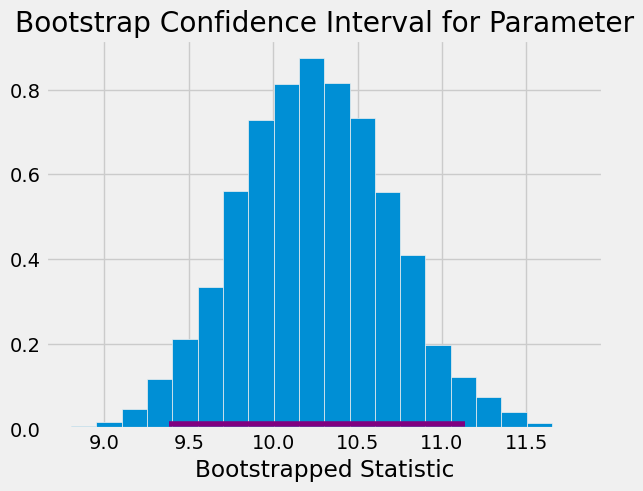

In [3]:
list_of_statistics_bootstrapped = np.array([np.mean(np.random.choice(data, size = 500)) for d in range(5000)])
plt.hist(list_of_statistics_bootstrapped, bins = 20, density = True)
plt.plot([np.percentile(list_of_statistics_bootstrapped, 2.5), np.percentile(list_of_statistics_bootstrapped, 97.5)], [0.01, 0.01], color='purple', lw=4)
plt.xlabel('Bootstrapped Statistic')
plt.title("Bootstrap Confidence Interval for Parameter");

If 10 is within the bootstrapped confidence interval, and hence, we cannot reject the null hypothesis at the 5% level.

If 10 is not within the bootstrapped confidence interval, then the data are compatible with the null hypothesis.

We will now see why confidence intervals can be used to perform tests as described above.

## Test and Level

It was mentioned in a pervious seminar that creating a test, or decision rule, is equivalent to the creation of a rejection region $R$.

Since the rejection region $R$ is the complement of the acceptance region $A$, hypothesis testing can also be framed as the creation of an acceptance region $A$.

Suppose $A$ is the acceptance region of a test of the null hypothesis $H_0$. Then $A$ is a set containing all possible samples $\textbf{X}$ such that we do not reject the null hypothesis.

The level of the test is $P_{H_0}(R) = \alpha$. Hence $P_{H_{0}}(A) = 1 - \alpha$.

## Level of Confidence

Assume we are estimating some parameter $\theta$.

We typically think of confidence intervals as a range of values of $\hat{\theta}$, but here we think in terms of the samples that generate the $\hat{\theta}$s.

Since the $\hat{\theta}$s are generated from data $\textbf{X}$, we can consider a confidence region $C(\textbf{X})$ which is a set of all samples that generate a $100 (1 - \alpha)$ % confidence interval for $\theta$.

Then for all $\theta$, $P_\theta(\theta \in C(\textbf{X})) = 1 - \alpha$

Here, it is important to remember that $\theta$ is fixed and $C(\textbf{X})$ is random.

## Duality of Hypothesis Testing and Confidence Intervals

Suppose we desire a level $\alpha$ test of the null hypothesis $H_0: \theta = \theta_0$.

The level of this test does not depend on the alternative hypothesis, and hence I have all the information I need to create a test (i.e. create an acceptance region).

$A = \{ \textbf{X} : \theta_{0} \in C(\textbf{X}) \}$

We can prove that this test's level is $\alpha$ using our assertion in the section above.

$P_{\theta_0}(\theta_0 \in C(\textbf{X})) = 1 - \alpha = P_{H_0}(A)$

Hence $P_{H_0}(R) = \alpha$.

We can see that confidence intervals and hypothesis tests are mirrors of one another. The set of values of $\theta$ in a 95% confidence interval are exactly the set of values $\theta_0$ for which our 5%-level test of $H_0: \theta = \theta_0$ would accept the null hypothesis.


## Generalized Likelihood Ratio Tests
The Neyman-Pearson Lemma is about testing two simple hypotheses using a likelihood ratio test. However, commonly one or both of our hypotheses is composite (for example, $\mu > 10$).

We will now develop a way to handle composite hypotheses in a likelihood ratio test.

Suppose we have hypotheses: 
- $H_0$: $\theta = \theta_0$
- $H_1$: $\theta \neq \theta_0$

### The Statistic
A first step in defining the generalized likelihood ratio is to find 

$$\Lambda_1 = \frac{\text{likelihood of the data under } \theta_0}{\displaystyle\max_{\theta \neq \theta_0} \text{likelihood of the data under } \theta}$$

Small values of $\Lambda_1$ favor the alternative.

For technical reasons, it is easier to compute
$$\Lambda = \frac{\text{likelihood of the data under } \theta_0}{\displaystyle\max_{\text{all }\theta} \text{likelihood of the data under } \theta}$$

Since $\Lambda = \min(\Lambda_1, 1)$, small values of $\Lambda$ favor the alternative.

Notice that the denominator is the value of the likelihood calculated at $\hat{\theta}$, the MLE of $\theta$.

### Example: Generalized LRT for the Normal Mean

Suppose we have data  $X_1,X_2,...,X_n$  i.i.d normal $(\mu,\sigma^2)$ with unknown $\mu$ and known $\sigma$. We will perform a generalized likelihood ratio test of two hypotheses:
- $H_0$: $\mu=\mu_0$
- $H_1$: $\mu\neq\mu_0$

We showed in Data 140 that the MLE of $\mu$ is $\bar{X}$, the sample mean. So we have:

$$\begin{aligned}\Lambda &=\frac{\displaystyle\prod_{i=1}^{n}\frac{1}{\sqrt{2\pi}\sigma}\exp\left\{-\frac{1}{2\sigma^2}(X_i-\mu_0)^2\right\}}{\displaystyle\prod_{i=1}^{n}\frac{1}{\sqrt{2\pi}\sigma}\exp\left\{-\frac{1}{2\sigma^2}(X_i-\bar{X})^2\right\}}\\ 
&=\exp\left\{-\frac{1}{2\sigma^2}\left(\sum_{i=1}^{n}(X_i-\mu_0)^2-\sum_{i=1}^{n}(X_i-\bar{X})^2\right)\right\}\end{aligned}$$

To simplify our formula, write $X_i - \mu_0 = (X_i - \bar{X}) + (\bar{X} - \mu_0)$. Then

$$\sum_{i=1}^{n}(X_i-\mu_0)^2 = \sum_{i=1}^{n}(X_i-\bar{X})^2+2\sum_{i=1}^{n}(X_i-\bar{X})(\bar{X}-\mu_0)+\sum_{i=1}^{n}(\bar{X}-\mu_0)^2$$

Since $\sum_{i=1}^{n}(X_i-\bar{X})=0$, we have 

$$\sum_{i=1}^{n}(X_i-\mu_0)^2 = \sum_{i=1}^{n}(X_i-\bar{X})^2+\sum_{i=1}^{n}(\bar{X}-\mu_0)^2$$

Hence,$$\Lambda=\exp\left\{-\frac{1}{2\sigma^2}(n(\bar{X}-\mu_0)^2)\right\}$$

Remember that small values of $\Lambda$ favor the alternative. Since $\log$ is an increasing function, large values of $-2\log(\Lambda)$ will favor the alternative. The reason for considering the function $-2\log(\Lambda)$ is the following wonderful fact:

$$-2\log({\Lambda}) ~=~ \left(\frac{\bar{X}-\mu_0}{\sigma/\sqrt{n}}\right)^2 ~=~ Z^2 ~~\text{ under } H_0$$

where $Z$ is standard normal. So, under $H_0$, $-2\log(\Lambda)$ has the chi-squared $(1)$ distribution. This makes it easy for us to construct a rejection region of any specified level $\alpha$:

- We will reject $H_0$ if the test statistic $\displaystyle{\left(\frac{\bar{X}-\mu_0}{\sigma/\sqrt{n}}\right)^2}$ exceeds the $100(1-\alpha)$ percentile of the $\chi_1^2$ distribution.

- *Two-tailed test:* Equivalently, we will reject $H_0$ if the test statistic $\displaystyle{\left\vert \frac{\bar{X}-\mu_0}{\sigma/\sqrt{n}} \right\vert}$ exceeds the $100(1-\alpha/2)$ percentile of the standard normal distribution.